# Lesson 2.6 — Lid-Driven Cavity Flow

## The "Hello World" of CFD

A square box filled with fluid. The top wall slides at $U=1$. The other three walls are
fixed. No inlet, no outlet. The lid drags the fluid in a giant recirculating vortex.

Why is this problem so important?

1. **Simple geometry**: unit square, no meshing complexity.
2. **Benchmark data exists**: Ghia et al. (1982) published reference solutions at Re = 100, 400, 1000, 3200.
3. **Tests everything**: pressure-velocity coupling, boundary conditions, convergence.
4. **Re-dependent**: at low Re: one steady vortex. At high Re: secondary corner vortices, eventually unsteady.

Every new CFD solver is validated against this case.

---

## Problem Setup

Domain: $[0,1] \times [0,1]$

Boundary conditions:
- Top ($y=1$): $u = 1$, $v = 0$ (moving lid)
- Bottom ($y=0$): $u = v = 0$ (no-slip wall)
- Left ($x=0$): $u = v = 0$ (no-slip wall)
- Right ($x=1$): $u = v = 0$ (no-slip wall)

Pressure: Neumann ($\partial p/\partial n = 0$) on all walls.

The Reynolds number $Re = UL/\nu$ with $U=1$, $L=1$, so $\nu = 1/Re$.

---

## Expected Flow Structure

| Re | Flow structure |
|----|----------------|
| 100 | One primary vortex, slight asymmetry |
| 400 | Primary vortex + small corner vortices |
| 1000 | Stronger corner vortices, center shifts |
| 3200 | Near-unsteady, strong secondary vortices |
| 10000 | Unsteady, periodic shedding |


Running lid-driven cavity at Re=100 ...
Done.


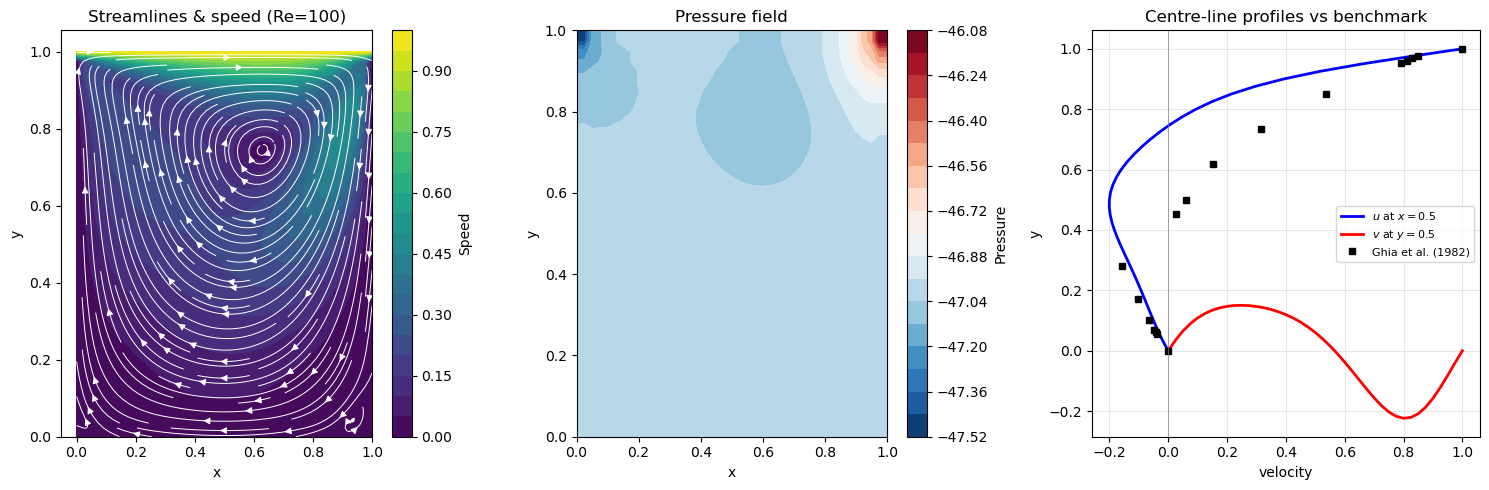

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def lid_driven_cavity(Re=100, N=41, n_steps=5000, dt=0.001):
    """
    Full lid-driven cavity solver using explicit time-stepping.
    Re: Reynolds number
    N:  grid points per side
    """
    nu  = 1.0 / Re
    rho = 1.0
    dx  = dy = 1.0 / (N - 1)

    u = np.zeros((N, N))
    v = np.zeros((N, N))
    p = np.zeros((N, N))

    # Lid BC
    u[-1, :] = 1.0

    def poisson(p, rhs, nit=50):
        for _ in range(nit):
            p[1:-1,1:-1] = (
                (p[1:-1,2:] + p[1:-1,:-2]) / dx**2 +
                (p[2:,1:-1] + p[:-2,1:-1]) / dy**2 -
                rhs[1:-1,1:-1]
            ) / (2/dx**2 + 2/dy**2)
            p[0,:]=p[1,:]; p[-1,:]=p[-2,:]
            p[:,0]=p[:,1]; p[:,-1]=p[:,-2]
        return p

    for _ in range(n_steps):
        un, vn = u.copy(), v.copy()

        # Build RHS for pressure (from velocity divergence)
        b = np.zeros_like(p)
        b[1:-1,1:-1] = (rho/dt * (
            (un[1:-1,2:] - un[1:-1,:-2]) / (2*dx) +
            (vn[2:,1:-1] - vn[:-2,1:-1]) / (2*dy))
            - ((un[1:-1,2:]-un[1:-1,:-2])/(2*dx))**2
            - 2*((un[2:,1:-1]-un[:-2,1:-1])/(2*dy))*((vn[1:-1,2:]-vn[1:-1,:-2])/(2*dx))
            - ((vn[2:,1:-1]-vn[:-2,1:-1])/(2*dy))**2)

        p = poisson(p, b)

        # Momentum update
        u[1:-1,1:-1] = (un[1:-1,1:-1]
            - un[1:-1,1:-1]*dt/dx*(un[1:-1,1:-1]-un[1:-1,:-2])
            - vn[1:-1,1:-1]*dt/dy*(un[1:-1,1:-1]-un[:-2,1:-1])
            - dt/(2*rho*dx)*(p[1:-1,2:]-p[1:-1,:-2])
            + nu*dt/dx**2*(un[1:-1,2:]-2*un[1:-1,1:-1]+un[1:-1,:-2])
            + nu*dt/dy**2*(un[2:,1:-1]-2*un[1:-1,1:-1]+un[:-2,1:-1]))

        v[1:-1,1:-1] = (vn[1:-1,1:-1]
            - un[1:-1,1:-1]*dt/dx*(vn[1:-1,1:-1]-vn[1:-1,:-2])
            - vn[1:-1,1:-1]*dt/dy*(vn[1:-1,1:-1]-vn[:-2,1:-1])
            - dt/(2*rho*dy)*(p[2:,1:-1]-p[:-2,1:-1])
            + nu*dt/dx**2*(vn[1:-1,2:]-2*vn[1:-1,1:-1]+vn[1:-1,:-2])
            + nu*dt/dy**2*(vn[2:,1:-1]-2*vn[1:-1,1:-1]+vn[:-2,1:-1]))

        # Apply BCs
        u[0,:]=0; u[:,0]=0; u[:,-1]=0; u[-1,:]=1.0
        v[0,:]=0; v[:,0]=0; v[:,-1]=0; v[-1,:]=0

    return u, v, p

print("Running lid-driven cavity at Re=100 ...")
u, v, p = lid_driven_cavity(Re=100, N=41, n_steps=4000)
print("Done.")

N = u.shape[0]
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Streamlines
speed = np.sqrt(u**2 + v**2)
cf0 = axes[0].contourf(X, Y, speed, levels=20, cmap='viridis')
plt.colorbar(cf0, ax=axes[0], label='Speed')
axes[0].streamplot(X, Y, u, v, color='white', density=1.5, linewidth=0.7)
axes[0].set_title('Streamlines & speed (Re=100)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Pressure
cf1 = axes[1].contourf(X, Y, p, levels=20, cmap='RdBu_r')
plt.colorbar(cf1, ax=axes[1], label='Pressure')
axes[1].set_title('Pressure field')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

# Velocity profiles along centre lines
j_mid = N // 2
i_mid = N // 2
axes[2].plot(u[:, i_mid], y, 'b-', linewidth=2, label='$u$ at $x=0.5$')
axes[2].plot(x, v[j_mid, :], 'r-', linewidth=2, label='$v$ at $y=0.5$')

# Ghia et al. (1982) benchmark data for Re=100, u along x=0.5
ghia_y  = [0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813,
            0.4531, 0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609,
            0.9688, 0.9766, 1.0000]
ghia_u  = [0.0000,-0.0372,-0.0419,-0.0477,-0.0643,-0.1015,-0.1571,
            0.0258, 0.0619, 0.1536, 0.3162, 0.5347, 0.7902, 0.8102,
            0.8300, 0.8486, 1.0000]
axes[2].plot(ghia_u, ghia_y, 'ks', markersize=5, label='Ghia et al. (1982)')
axes[2].axvline(0, color='gray', linewidth=0.5)
axes[2].set_xlabel('velocity'); axes[2].set_ylabel('y')
axes[2].set_title('Centre-line profiles vs benchmark')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Takeaways

- The lid-driven cavity is the standard validation case for incompressible N-S solvers.
- Always compare against Ghia et al. (1982) benchmark data — any discrepancy reveals a bug.
- At Re=100: single vortex. At Re=1000: secondary corner vortices appear.
- The solver here is a simplified explicit method — SIMPLE (Lesson 2.5) is more robust.
- Key failure modes: CFL violation (dt too large), insufficient Poisson iterations, wrong BCs.

---

**Next**: Lesson 2.7 — Flow over a Cylinder: external flow, drag/lift, Kármán vortex street.
